In [1]:
import torch as t
import torchaudio

In [7]:
import torchaudio.transforms as T
from tqdm import tqdm 


In [8]:
# mel_transform = T.MelSpectrogram(
#     sample_rate=sample_rate,
#     n_fft=n_fft,
#     hop_length=hop_length,
#     n_mels=n_mels
# )

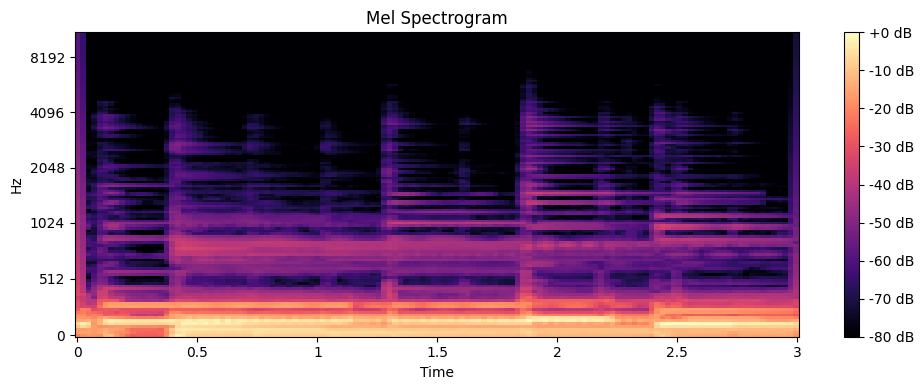

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load the audio file
audio_path = '/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Bass_Guitar/300.wav'
y, sr = librosa.load(audio_path, duration=3.0)  # Load 3 seconds

# Generate Mel spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=y, 
    sr=sr,
    n_fft=2048,        # FFT window size
    hop_length=512,    # Number of samples between frames
    n_mels=128         # Number of Mel bands
)

# Convert to decibel scale (log scale)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Visualize
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.show()

In [10]:
# class AudioConverter:
#     """
#     Convert audio files to Mel spectrograms and save them.
    
#     Expected input structure:
#     input_folder/
#         piano/
#             audio1.wav
#             audio2.wav
#         guitar/
#             audio1.wav
#         violin/
#             audio1.wav
    
#     Output structure:
#     output_folder/
#         piano/
#             audio1.npy  (or .png)
#             audio2.npy
#         guitar/
#             audio1.npy
#         metadata.json
#     """
    
#     def __init__(self, sample_rate=22050, duration=3, n_mels=128, n_fft=2048, hop_length=512):
#         """
#         Initialize the converter with audio parameters.
        
#         Args:
#             sample_rate: Target sample rate (Hz)
#             duration: Duration of audio clips (seconds)
#             n_mels: Number of mel bands
#             n_fft: FFT window size
#             hop_length: Number of samples between frames
#         """
#         self.sample_rate = sample_rate
#         self.duration = duration
#         self.target_length = sample_rate * duration
#         self.n_mels = n_mels
#         self.n_fft = n_fft
#         self.hop_length = hop_length
        
#         # Create mel spectrogram transform
#         # self.mel_transform = T.MelSpectrogram(
#         #     sample_rate=sample_rate,
#         #     n_fft=n_fft,
#         #     hop_length=hop_length,
#         #     n_mels=n_mels
#         # )
        
#         # Convert to dB scale
#         self.amplitude_to_db = T.AmplitudeToDB()

#     def load_and_preprocess_audio(self, audio_path):
#         """
#         Load audio file and preprocess it.
        
#         Args:
#             audio_path: Path to audio file
            
#         Returns:
#             Preprocessed waveform tensor
#         """
#         try:
#             # Load audio
#             waveform, sr = torchaudio.load(audio_path)
            
#             # Resample if needed
#             if sr != self.sample_rate:
#                 resampler = T.Resample(sr, self.sample_rate)
#                 waveform = resampler(waveform)
            
#             # Convert to mono if stereo
#             if waveform.shape[0] > 1:
#                 waveform = torch.mean(waveform, dim=0, keepdim=True)
            
#             # Pad or trim to fixed length (3 seconds)
#             if waveform.shape[1] < self.target_length:
#                 # Pad with zeros
#                 padding = self.target_length - waveform.shape[1]
#                 waveform = torch.nn.functional.pad(waveform, (0, padding))
#             else:
#                 # Trim to target length
#                 waveform = waveform[:, :self.target_length]
            
#             return waveform
        
#         except Exception as e:
#             print(f"Error loading {audio_path}: {e}")
#             return None

#     def audio_to_mel_spectrogram(self, waveform, normalize=True):
#         """
#         Convert audio waveform to mel spectrogram.
        
#         Args:
#             waveform: Audio waveform tensor
#             normalize: Whether to normalize the spectrogram
            
#         Returns:
#             Mel spectrogram tensor
#         """
#         # Convert to mel spectrogram
#         mel_spec = self.mel_transform(waveform)
        
#         # Convert to dB scale
#         mel_spec_db = self.amplitude_to_db(mel_spec)
        
#         # Normalize
#         if normalize:
#             mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-9)
        
#         return mel_spec_db

#     def save_mel_spectrogram(self, mel_spec, output_path, save_format='npy'):
#         mel_spec_np = mel_spec.squeeze(0).numpy()

#         if save_format == 'npy':
#             np.save(f"{output_path}.npy", mel_spec_np)

#         elif save_format == 'png':
#             png_path = f"{output_path}.png"

#             # ✅ NEW: Skip if already exists
#             if os.path.exists(png_path):
#                 return
            
#             plt.figure(figsize=(10, 4))
#             plt.imshow(mel_spec_np, aspect='auto', origin='lower', cmap='viridis')
#             plt.colorbar(format='%+2.0f dB')
#             plt.title('Mel Spectrogram')
#             plt.xlabel('Time')
#             plt.ylabel('Mel Frequency')
#             plt.tight_layout()
#             plt.savefig(png_path, dpi=150, bbox_inches='tight')
#             plt.close()

#     def convert_dataset(self, input_dir, output_dir, save_format='npy', visualize_samples=5):
#         """
#         Convert entire dataset from audio to mel spectrograms.
        
#         Args:
#             input_dir: Directory containing audio files organized by class
#             output_dir: Directory to save mel spectrograms
#             save_format: 'npy' or 'png' or 'both'
#             visualize_samples: Number of samples to visualize (saved as PNG)
#         """
#         input_path = Path(input_dir)
#         output_path = Path(output_dir)
        
#         # Create output directory
#         output_path.mkdir(parents=True, exist_ok=True)
        
#         # Get all instrument classes (subdirectories)
#         classes = sorted([d.name for d in input_path.iterdir() if d.is_dir()])
        
#         if not classes:
#             print(f"No subdirectories found in {input_dir}")
#             return
        
#         print(f"Found {len(classes)} classes: {classes}")
        
#         # Statistics
#         stats = {
#             'total_files': 0,
#             'successful': 0,
#             'failed': 0,
#             'classes': {},
#             'parameters': {
#                 'sample_rate': self.sample_rate,
#                 'duration': self.duration,
#                 'n_mels': self.n_mels,
#                 'n_fft': self.n_fft,
#                 'hop_length': self.hop_length
#             }
#         }
        
#         # Process each class
#         for class_name in classes:
#             print(f"\nProcessing class: {class_name}")
            
#             class_input_dir = input_path / class_name
#             class_output_dir = output_path / class_name
#             class_output_dir.mkdir(parents=True, exist_ok=True)
            
#             # Get all audio files in this class
#             audio_extensions = ['.wav', '.mp3', '.flac', '.ogg', '.m4a']
#             audio_files = []
#             for ext in audio_extensions:
#                 audio_files.extend(list(class_input_dir.glob(f'*{ext}')))
            
#             if not audio_files:
#                 print(f"  No audio files found in {class_input_dir}")
#                 continue
            
#             print(f"  Found {len(audio_files)} audio files")
#             stats['classes'][class_name] = len(audio_files)
            
#             # Process each audio file
#             visualized_count = 0
#             for audio_file in tqdm(audio_files, desc=f"  Converting {class_name}"):
#                 stats['total_files'] += 1
                
#                 # Load and preprocess audio
#                 waveform = self.load_and_preprocess_audio(audio_file)
                
#                 if waveform is None:
#                     stats['failed'] += 1
#                     continue
                
#                 # Convert to mel spectrogram
#                 mel_spec = self.audio_to_mel_spectrogram(waveform)
                
#                 # Output filename (same as input but different extension)
#                 output_name = class_output_dir / audio_file.stem
                
#                 # Save based on format
#                 if save_format in ['npy', 'both']:
#                     self.save_mel_spectrogram(mel_spec, output_name, 'npy')
                
#                 if save_format in ['png', 'both']:
#                     self.save_mel_spectrogram(mel_spec, output_name, 'png')
                
#                 # Visualize first few samples
#                 if visualized_count < visualize_samples:
#                     viz_path = class_output_dir / f"{audio_file.stem}_viz"
#                     self.save_mel_spectrogram(mel_spec, viz_path, 'png')
#                     visualized_count += 1
                
#                 stats['successful'] += 1
        
#         # Save metadata
#         metadata_path = output_path / 'metadata.json'
#         with open(metadata_path, 'w') as f:
#             json.dump(stats, f, indent=2)
        
#         print("\n" + "="*60)
#         print("Conversion Complete!")
#         print("="*60)
#         print(f"Total files processed: {stats['total_files']}")
#         print(f"Successful conversions: {stats['successful']}")
#         print(f"Failed conversions: {stats['failed']}")
#         print(f"\nClass distribution:")
#         for class_name, count in stats['classes'].items():
#             print(f"  {class_name}: {count} files")
#         print(f"\nOutput saved to: {output_path}")
#         print(f"Metadata saved to: {metadata_path}")

#     def visualize_single_file(self, audio_path, save_path=None):
#         """
#         Visualize a single audio file as mel spectrogram.
        
#         Args:
#             audio_path: Path to audio file
#             save_path: Path to save visualization (optional)
#         """
#         print(f"Processing: {audio_path}")
        
#         # Load and preprocess
#         waveform = self.load_and_preprocess_audio(audio_path)
#         if waveform is None:
#             return
        
#         # Convert to mel spectrogram
#         mel_spec = self.audio_to_mel_spectrogram(waveform)
#         mel_spec_np = mel_spec.squeeze(0).numpy()
        
#         # Create figure with waveform and spectrogram
#         fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
#         # Plot waveform
#         time_axis = np.linspace(0, self.duration, waveform.shape[1])
#         ax1.plot(time_axis, waveform.squeeze().numpy())
#         ax1.set_title('Audio Waveform')
#         ax1.set_xlabel('Time (s)')
#         ax1.set_ylabel('Amplitude')
#         ax1.grid(True, alpha=0.3)
        
#         # Plot mel spectrogram
#         img = ax2.imshow(mel_spec_np, aspect='auto', origin='lower', 
#                         cmap='viridis', extent=[0, self.duration, 0, self.n_mels])
#         ax2.set_title('Mel Spectrogram')
#         ax2.set_xlabel('Time (s)')
#         ax2.set_ylabel('Mel Frequency Bin')
#         plt.colorbar(img, ax=ax2, format='%+2.0f dB')
        
#         plt.tight_layout()
        
#         if save_path:
#             plt.savefig(save_path, dpi=150, bbox_inches='tight')
#             print(f"Saved visualization to: {save_path}")
#         else:
#             plt.show()
        
#         plt.close()


In [11]:
converter = AudioConverter()

# Test with your bass guitar file
converter.visualize_single_file(
    audio_path='/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Bass_Guitar/300.wav',
    save_path='test_visualization.png'
)


NameError: name 'AudioConverter' is not defined

In [12]:
converter = AudioConverter()

# Test single file
converter.visualize_single_file(
    audio_path='/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Bass_Guitar/300.wav',
    save_path='test_visualization.png'
)

NameError: name 'AudioConverter' is not defined

In [13]:
import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
# from tqdm import tqdm
import json

class AudioConverter:
    """
    Convert audio files to Mel spectrograms and save them.
    
    Expected input structure:
    input_folder/
        piano/
            audio1.wav
            audio2.wav
        guitar/
            audio1.wav
        violin/
            audio1.wav
    
    Output structure:
    output_folder/
        piano/
            audio1.npy  (or .png)
            audio2.npy
        guitar/
            audio1.npy
        metadata.json
    """
    
    def __init__(self, sample_rate=22050, duration=3, n_mels=128, n_fft=2048, hop_length=512):
        """
        Initialize the converter with audio parameters.
        
        Args:
            sample_rate: Target sample rate (Hz)
            duration: Duration of audio clips (seconds)
            n_mels: Number of mel bands
            n_fft: FFT window size
            hop_length: Number of samples between frames
        """
        self.sample_rate = sample_rate
        self.duration = duration
        self.target_length = sample_rate * duration
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
    
    def load_and_preprocess_audio(self, audio_path):
        """
        Load audio file and preprocess it using librosa.
        
        Args:
            audio_path: Path to audio file
            
        Returns:
            Preprocessed waveform as numpy array
        """
        try:
            # Load audio with librosa (automatically resamples and converts to mono)
            y, sr = librosa.load(audio_path, sr=self.sample_rate, duration=self.duration, mono=True)
            
            # Pad or trim to exact target length
            if len(y) < self.target_length:
                # Pad with zeros
                y = np.pad(y, (0, self.target_length - len(y)), mode='constant')
            else:
                # Trim to target length
                y = y[:self.target_length]
            
            return y
        
        except Exception as e:
            print(f"Error loading {audio_path}: {e}")
            return None
    
    def audio_to_mel_spectrogram(self, waveform, normalize=True):
        """
        Convert audio waveform to mel spectrogram using librosa.
        
        Args:
            waveform: Audio waveform as numpy array
            normalize: Whether to normalize the spectrogram
            
        Returns:
            Mel spectrogram as numpy array
        """
        # Generate mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=waveform,
            sr=self.sample_rate,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )
        
        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Normalize
        if normalize:
            mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-9)
        
        return mel_spec_db
    
    def save_mel_spectrogram(self, mel_spec, output_path, save_format='npy'):
        """
        Save mel spectrogram to file.
        
        Args:
            mel_spec: Mel spectrogram as numpy array
            output_path: Output file path (without extension)
            save_format: 'npy' for numpy array or 'png' for image
        """
        if save_format == 'npy':
            np.save(f"{output_path}.npy", mel_spec)

        elif save_format == 'png':
            png_path = f"{output_path}.png"

            # Skip if already exists
            if os.path.exists(png_path):
                return
            
            plt.figure(figsize=(10, 4))
            plt.imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
            plt.colorbar(format='%+2.0f dB')
            plt.title('Mel Spectrogram')
            plt.xlabel('Time')
            plt.ylabel('Mel Frequency')
            plt.tight_layout()
            plt.savefig(png_path, dpi=150, bbox_inches='tight')
            plt.close()
    
    def convert_dataset(self, input_dir, output_dir, save_format='npy', visualize_samples=5):
        """
        Convert entire dataset from audio to mel spectrograms.
        
        Args:
            input_dir: Directory containing audio files organized by class
            output_dir: Directory to save mel spectrograms
            save_format: 'npy' or 'png' or 'both'
            visualize_samples: Number of samples to visualize (saved as PNG)
        """
        input_path = Path(input_dir)
        output_path = Path(output_dir)
        
        # Create output directory
        output_path.mkdir(parents=True, exist_ok=True)
        
        # Get all instrument classes (subdirectories)
        classes = sorted([d.name for d in input_path.iterdir() if d.is_dir()])
        
        if not classes:
            print(f"No subdirectories found in {input_dir}")
            return
        
        print(f"Found {len(classes)} classes: {classes}")
        
        # Statistics
        stats = {
            'total_files': 0,
            'successful': 0,
            'failed': 0,
            'classes': {},
            'parameters': {
                'sample_rate': self.sample_rate,
                'duration': self.duration,
                'n_mels': self.n_mels,
                'n_fft': self.n_fft,
                'hop_length': self.hop_length
            }
        }
        
        # Process each class
        for class_name in classes:
            print(f"\nProcessing class: {class_name}")
            
            class_input_dir = input_path / class_name
            class_output_dir = output_path / class_name
            class_output_dir.mkdir(parents=True, exist_ok=True)
            
            # Get all audio files in this class
            audio_extensions = ['.wav', '.mp3', '.flac', '.ogg', '.m4a']
            audio_files = []
            for ext in audio_extensions:
                audio_files.extend(list(class_input_dir.glob(f'*{ext}')))
            
            if not audio_files:
                print(f"  No audio files found in {class_input_dir}")
                continue
            
            print(f"  Found {len(audio_files)} audio files")
            stats['classes'][class_name] = len(audio_files)
            
            # Process each audio file
            visualized_count = 0
            for audio_file in tqdm(audio_files, desc=f"  Converting {class_name}"):
                stats['total_files'] += 1
                
                # Load and preprocess audio
                waveform = self.load_and_preprocess_audio(audio_file)
                
                if waveform is None:
                    stats['failed'] += 1
                    continue
                
                # Convert to mel spectrogram
                mel_spec = self.audio_to_mel_spectrogram(waveform)
                
                # Output filename (same as input but different extension)
                output_name = class_output_dir / audio_file.stem
                
                # Save based on format
                if save_format in ['npy', 'both']:
                    self.save_mel_spectrogram(mel_spec, output_name, 'npy')
                
                if save_format in ['png', 'both']:
                    self.save_mel_spectrogram(mel_spec, output_name, 'png')
                
                # Visualize first few samples
                if visualized_count < visualize_samples:
                    viz_path = class_output_dir / f"{audio_file.stem}_viz"
                    self.save_mel_spectrogram(mel_spec, viz_path, 'png')
                    visualized_count += 1
                
                stats['successful'] += 1
        
        # Save metadata
        metadata_path = output_path / 'metadata.json'
        with open(metadata_path, 'w') as f:
            json.dump(stats, f, indent=2)
        
        print("\n" + "="*60)
        print("Conversion Complete!")
        print("="*60)
        print(f"Total files processed: {stats['total_files']}")
        print(f"Successful conversions: {stats['successful']}")
        print(f"Failed conversions: {stats['failed']}")
        print(f"\nClass distribution:")
        for class_name, count in stats['classes'].items():
            print(f"  {class_name}: {count} files")
        print(f"\nOutput saved to: {output_path}")
        print(f"Metadata saved to: {metadata_path}")
    
    def visualize_single_file(self, audio_path, save_path=None):
        """
        Visualize a single audio file as mel spectrogram.
        
        Args:
            audio_path: Path to audio file
            save_path: Path to save visualization (optional)
        """
        print(f"Processing: {audio_path}")
        
        # Load and preprocess
        waveform = self.load_and_preprocess_audio(audio_path)
        if waveform is None:
            return
        
        # Convert to mel spectrogram
        mel_spec = self.audio_to_mel_spectrogram(waveform)
        
        # Create figure with waveform and spectrogram
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        # Plot waveform
        time_axis = np.linspace(0, self.duration, len(waveform))
        ax1.plot(time_axis, waveform)
        ax1.set_title('Audio Waveform')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Amplitude')
        ax1.grid(True, alpha=0.3)
        
        # Plot mel spectrogram
        img = ax2.imshow(mel_spec, aspect='auto', origin='lower', 
                        cmap='viridis', extent=[0, self.duration, 0, self.n_mels])
        ax2.set_title('Mel Spectrogram')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Mel Frequency Bin')
        plt.colorbar(img, ax=ax2, format='%+2.0f dB')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Saved visualization to: {save_path}")
        else:
            plt.show()
        
        plt.close()


# ============================================
# USAGE EXAMPLES
# ============================================

if __name__ == "__main__":
    # Initialize converter with your settings
    converter = AudioConverter(
        sample_rate=22050,
        duration=3,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )
    
    # OPTION 1: Visualize a single file first to test
    print("Visualizing single file...")
    converter.visualize_single_file(
        audio_path='/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Bass_Guitar/300.wav',
        save_path='test_visualization.png'
    )
    
    # OPTION 2: Convert entire dataset
    # Uncomment when ready to process all files
    """
    print("\nConverting entire dataset...")
    converter.convert_dataset(
        input_dir='/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset',
        output_dir='/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/mel_spectrograms',
        save_format='npy',  # or 'both' to save PNG too
        visualize_samples=3
    )
    """

Visualizing single file...
Processing: /Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Bass_Guitar/300.wav
Saved visualization to: test_visualization.png


In [14]:
from pathlib import Path

# Initialize converter
converter = AudioConverter(
    sample_rate=22050,
    duration=3,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

# Convert your entire dataset
converter.convert_dataset(
    input_dir='/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset',
    output_dir='/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/mel_spectrograms',
    save_format='npy',
    visualize_samples=0  # No PNGs, just .npy files
)

Found 28 classes: ['Accordion', 'Acoustic_Guitar', 'Banjo', 'Bass_Guitar', 'Clarinet', 'Cymbals', 'Dobro', 'Drum_set', 'Electro_Guitar', 'Floor_Tom', 'Harmonica', 'Harmonium', 'Hi_Hats', 'Horn', 'Keyboard', 'Mandolin', 'Organ', 'Piano', 'Saxophone', 'Shakers', 'Tambourine', 'Trombone', 'Trumpet', 'Ukulele', 'Violin', 'cowbell', 'flute', 'vibraphone']

Processing class: Accordion
  Found 3581 audio files


  Converting Accordion: 100%|██████████| 3581/3581 [00:12<00:00, 296.02it/s]



Processing class: Acoustic_Guitar
  Found 3654 audio files


  Converting Acoustic_Guitar: 100%|██████████| 3654/3654 [00:12<00:00, 304.26it/s]



Processing class: Banjo
  Found 2998 audio files


...


Processing class: flute
  Found 3719 audio files


  Converting flute: 100%|██████████| 3719/3719 [00:12<00:00, 308.62it/s]



Processing class: vibraphone
  Found 506 audio files


  Converting vibraphone: 100%|██████████| 506/506 [00:01<00:00, 307.01it/s]


Conversion Complete!
Total files processed: 42311
Successful conversions: 42311
Failed conversions: 0

Class distribution:
  Accordion: 3581 files
  Acoustic_Guitar: 3654 files
  Banjo: 2998 files
  Bass_Guitar: 3613 files
  Clarinet: 634 files
  Cymbals: 208 files
  Dobro: 487 files
  Drum_set: 3648 files
  Electro_Guitar: 1316 files
  Floor_Tom: 406 files
  Harmonica: 131 files
  Harmonium: 1314 files
  Hi_Hats: 444 files
  Horn: 1258 files
  Keyboard: 2041 files
  Mandolin: 2458 files
  Organ: 1442 files
  Piano: 575 files
  Saxophone: 454 files
  Shakers: 1357 files
  Tambourine: 558 files
  Trombone: 2965 files
  Trumpet: 503 files
  Ukulele: 790 files
  Violin: 630 files
  cowbell: 621 files
  flute: 3719 files
  vibraphone: 506 files

Output saved to: /Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/mel_spectrograms
Metadata saved to: /Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/mel_spectrograms/metadata.json


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

# ============================================
# 1. DATASET CLASS FOR MEL SPECTROGRAMS
# ============================================
class MelSpectrogramDataset(Dataset):
    """
    Dataset class for loading pre-computed mel spectrograms.
    """
    def __init__(self, file_paths, labels, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
    
    def __len__(self):
        return len(self.file_paths)
    
    def augment_spectrogram(self, mel_spec):
        """Apply random augmentations to mel spectrogram"""
        # Time masking (mask random time frames)
        if np.random.rand() > 0.5:
            t_mask_width = np.random.randint(0, 20)
            t_start = np.random.randint(0, mel_spec.shape[1] - t_mask_width)
            mel_spec[:, t_start:t_start + t_mask_width] = mel_spec.mean()
        
        # Frequency masking (mask random frequency bins)
        if np.random.rand() > 0.5:
            f_mask_width = np.random.randint(0, 20)
            f_start = np.random.randint(0, mel_spec.shape[0] - f_mask_width)
            mel_spec[f_start:f_start + f_mask_width, :] = mel_spec.mean()
        
        return mel_spec
    
    def __getitem__(self, idx):
        # Load mel spectrogram from .npy file
        mel_spec = np.load(self.file_paths[idx])
        
        # Apply augmentation if training
        if self.augment:
            mel_spec = self.augment_spectrogram(mel_spec.copy())
        
        # Add channel dimension (1, H, W) for CNN
        mel_spec = np.expand_dims(mel_spec, axis=0)
        
        # Convert to tensor
        mel_spec = torch.FloatTensor(mel_spec)
        label = torch.LongTensor([self.labels[idx]])[0]
        
        return mel_spec, label




In [2]:
# ============================================
# 2. CNN MODEL ARCHITECTURE
# ============================================
class InstrumentCNN(nn.Module):
    """CNN for instrument classification from mel spectrograms"""
    def __init__(self, num_classes):
        super(InstrumentCNN, self).__init__()
        
        # Convolutional layers
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x




In [3]:
# ============================================
# 3. DATA PREPARATION
# ============================================
def prepare_mel_data(mel_spec_dir, test_size=0.2, val_size=0.1):
    """
    Prepare dataset from mel spectrogram directory.
    
    Args:
        mel_spec_dir: Directory containing mel spectrograms organized by class
        test_size: Proportion of data for testing
        val_size: Proportion of training data for validation
    
    Returns:
        Train, validation, and test splits with class information
    """
    mel_path = Path(mel_spec_dir)
    file_paths = []
    labels = []
    
    # Get all instrument classes
    classes = sorted([d.name for d in mel_path.iterdir() if d.is_dir()])
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    
    print(f"Found {len(classes)} classes: {classes}")
    
    # Collect all .npy files
    for cls in classes:
        cls_path = mel_path / cls
        npy_files = list(cls_path.glob('*.npy'))
        print(f"  {cls}: {len(npy_files)} files")
        
        for npy_file in npy_files:
            file_paths.append(str(npy_file))
            labels.append(class_to_idx[cls])
    
    print(f"\nTotal files: {len(file_paths)}")
    
    # Split data
    X_temp, X_test, y_temp, y_test = train_test_split(
        file_paths, labels, test_size=test_size, stratify=labels, random_state=42
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size/(1-test_size), stratify=y_temp, random_state=42
    )
    
    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, classes, class_to_idx




In [4]:
# ============================================
# 4. TRAINING FUNCTIONS
# ============================================
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(dataloader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_loss = running_loss / len(dataloader)
    val_acc = 100. * correct / total
    return val_loss, val_acc




In [5]:
# ============================================
# 5. MAIN TRAINING FUNCTION
# ============================================
def train_instrument_classifier(mel_spec_dir, num_epochs=50, batch_size=32, lr=0.001):
    """
    Train the instrument classification model.
    
    Args:
        mel_spec_dir: Directory containing mel spectrograms
        num_epochs: Number of training epochs
        batch_size: Batch size for training
        lr: Learning rate
    
    Returns:
        Trained model, training history, and class information
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}\n")
    
    # Prepare data
    print("Loading data...")
    X_train, X_val, X_test, y_train, y_val, y_test, classes, class_to_idx = prepare_mel_data(mel_spec_dir)
    
    # Create datasets
    train_dataset = MelSpectrogramDataset(X_train, y_train, augment=True)
    val_dataset = MelSpectrogramDataset(X_val, y_val, augment=False)
    test_dataset = MelSpectrogramDataset(X_test, y_test, augment=False)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # Initialize model
    model = InstrumentCNN(num_classes=len(classes)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    # Training loop
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    
    print("\nStarting training...\n")
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'classes': classes,
                'class_to_idx': class_to_idx
            }, 'best_instrument_model.pth')
            print(f"  ✓ Saved best model (Val Acc: {val_acc:.2f}%)")
        print()
    
    # Test evaluation
    print("Evaluating on test set...")
    test_loss, test_acc = validate(model, test_loader, criterion, device)
    print(f"\nFinal Test Accuracy: {test_acc:.2f}%")
    
    # Plot training history
    plot_training_history(history)
    
    return model, history, classes, class_to_idx


In [6]:
# ============================================
# 6. VISUALIZATION
# ============================================
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    print("Saved training history plot to: training_history.png")
    plt.show()




In [7]:
# ============================================
# 7. INFERENCE
# ============================================
def predict_instrument(model_path, mel_spec_path, device='cpu'):
    """
    Predict instrument from a mel spectrogram file.
    
    Args:
        model_path: Path to saved model
        mel_spec_path: Path to mel spectrogram .npy file
        device: Device to run inference on
    
    Returns:
        Predicted class name and confidence
    """
    # Load model
    checkpoint = torch.load(model_path, map_location=device)
    classes = checkpoint['classes']
    
    model = InstrumentCNN(num_classes=len(classes))
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    # Load mel spectrogram
    mel_spec = np.load(mel_spec_path)
    mel_spec = np.expand_dims(mel_spec, axis=0)  # Add channel dimension
    mel_spec = torch.FloatTensor(mel_spec).unsqueeze(0).to(device)  # Add batch dimension
    
    # Predict
    with torch.no_grad():
        output = model(mel_spec)
        probabilities = torch.softmax(output, dim=1)
        predicted_idx = output.argmax(1).item()
        confidence = probabilities[0][predicted_idx].item()
    
    return classes[predicted_idx], confidence


# ============================================
# 8. USAGE EXAMPLE
# ============================================
if __name__ == "__main__":
    # Train the model
    mel_spec_directory = "/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/mel_spectrograms"
    
    model, history, classes, class_to_idx = train_instrument_classifier(
        mel_spec_dir=mel_spec_directory,
        num_epochs=50,
        batch_size=32,
        lr=0.001
    )
    
    # Make a prediction
    # instrument, confidence = predict_instrument(
    #     model_path='best_instrument_model.pth',
    #     mel_spec_path='path/to/test/spectrogram.npy'
    # )
    # print(f"Predicted: {instrument} (confidence: {confidence:.2%})")

Using device: cpu

Loading data...
Found 28 classes: ['Accordion', 'Acoustic_Guitar', 'Banjo', 'Bass_Guitar', 'Clarinet', 'Cymbals', 'Dobro', 'Drum_set', 'Electro_Guitar', 'Floor_Tom', 'Harmonica', 'Harmonium', 'Hi_Hats', 'Horn', 'Keyboard', 'Mandolin', 'Organ', 'Piano', 'Saxophone', 'Shakers', 'Tambourine', 'Trombone', 'Trumpet', 'Ukulele', 'Violin', 'cowbell', 'flute', 'vibraphone']
  Accordion: 3581 files
  Acoustic_Guitar: 3654 files
  Banjo: 2998 files
  Bass_Guitar: 3613 files
  Clarinet: 634 files
  Cymbals: 208 files
  Dobro: 487 files
  Drum_set: 3648 files
  Electro_Guitar: 1316 files
  Floor_Tom: 406 files
  Harmonica: 131 files
  Harmonium: 1314 files
  Hi_Hats: 444 files
  Horn: 1258 files
  Keyboard: 2041 files
  Mandolin: 2458 files
  Organ: 1442 files
  Piano: 575 files
  Saxophone: 454 files
  Shakers: 1357 files
  Tambourine: 558 files
  Trombone: 2965 files
  Trumpet: 503 files
  Ukulele: 790 files
  Violin: 630 files
  cowbell: 621 files
  flute: 3719 files
  vibrap

Epoch 1/50
  Train Loss: 0.9543, Train Acc: 72.15%
  Val Loss: 0.4764, Val Acc: 85.37%
  ✓ Saved best model (Val Acc: 85.37%)



Epoch 2/50
  Train Loss: 0.5132, Train Acc: 84.28%
  Val Loss: 0.4274, Val Acc: 86.81%
  ✓ Saved best model (Val Acc: 86.81%)



Epoch 3/50
  Train Loss: 0.3959, Train Acc: 88.07%
  Val Loss: 0.2616, Val Acc: 91.42%
  ✓ Saved best model (Val Acc: 91.42%)



Epoch 4/50
  Train Loss: 0.3227, Train Acc: 90.10%
  Val Loss: 0.1904, Val Acc: 94.26%
  ✓ Saved best model (Val Acc: 94.26%)



...

Epoch 7/50
  Train Loss: 0.2070, Train Acc: 93.61%
  Val Loss: 0.1489, Val Acc: 95.06%



Epoch 8/50
  Train Loss: 0.1867, Train Acc: 94.15%
  Val Loss: 0.1063, Val Acc: 96.74%
  ✓ Saved best model (Val Acc: 96.74%)



Epoch 9/50
  Train Loss: 0.1709, Train Acc: 94.67%
  Val Loss: 0.1188, Val Acc: 96.60%



Epoch 10/50
  Train Loss: 0.1539, Train Acc: 95.11%
  Val Loss: 0.0971, Val Acc: 97.23%
  ✓ Saved best model (Val Acc: 97.23%)



KeyboardInterrupt: 

In [8]:
import torch
import torch.nn as nn
import librosa
import numpy as np
from pathlib import Path

# ============================================
# 1. CNN MODEL (same as training)
# ============================================
class InstrumentCNN(nn.Module):
    """CNN for instrument classification from mel spectrograms"""
    def __init__(self, num_classes):
        super(InstrumentCNN, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


# ============================================
# 2. AUDIO PREPROCESSING
# ============================================
class AudioPreprocessor:
    """Convert raw audio to mel spectrogram (same as training)"""
    def __init__(self, sample_rate=22050, duration=3, n_mels=128, n_fft=2048, hop_length=512):
        self.sample_rate = sample_rate
        self.duration = duration
        self.target_length = sample_rate * duration
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
    
    def load_audio(self, audio_path):
        """Load and preprocess audio file"""
        try:
            # Load audio with librosa
            y, sr = librosa.load(audio_path, sr=self.sample_rate, duration=self.duration, mono=True)
            
            # Pad or trim to exact target length
            if len(y) < self.target_length:
                y = np.pad(y, (0, self.target_length - len(y)), mode='constant')
            else:
                y = y[:self.target_length]
            
            return y
        except Exception as e:
            print(f"Error loading audio: {e}")
            return None
    
    def audio_to_mel_spectrogram(self, waveform):
        """Convert audio to mel spectrogram"""
        # Generate mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=waveform,
            sr=self.sample_rate,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )
        
        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Normalize (same as training)
        mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-9)
        
        return mel_spec_db
    
    def preprocess(self, audio_path):
        """Full preprocessing pipeline"""
        waveform = self.load_audio(audio_path)
        if waveform is None:
            return None
        
        mel_spec = self.audio_to_mel_spectrogram(waveform)
        return mel_spec


# ============================================
# 3. INSTRUMENT PREDICTOR
# ============================================
class InstrumentPredictor:
    """Complete pipeline for predicting instrument from audio"""
    def __init__(self, model_path, device='cpu'):
        """
        Initialize predictor with trained model.
        
        Args:
            model_path: Path to saved model (.pth file)
            device: 'cpu' or 'cuda'
        """
        self.device = torch.device(device)
        
        # Load model checkpoint
        print(f"Loading model from: {model_path}")
        checkpoint = torch.load(model_path, map_location=self.device)
        
        self.classes = checkpoint['classes']
        print(f"Loaded model with {len(self.classes)} classes: {self.classes}")
        
        # Initialize model
        self.model = InstrumentCNN(num_classes=len(self.classes))
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()
        
        # Initialize audio preprocessor
        self.preprocessor = AudioPreprocessor()
        
        print("Model ready for predictions!\n")
    
    def predict(self, audio_path, top_k=3):
        """
        Predict instrument from audio file.
        
        Args:
            audio_path: Path to audio file (.wav, .mp3, etc.)
            top_k: Return top-k predictions
        
        Returns:
            Dictionary with predictions and confidences
        """
        print(f"Processing: {audio_path}")
        
        # Preprocess audio to mel spectrogram
        mel_spec = self.preprocessor.preprocess(audio_path)
        
        if mel_spec is None:
            return None
        
        # Convert to tensor and add batch + channel dimensions
        mel_spec = torch.FloatTensor(mel_spec).unsqueeze(0).unsqueeze(0).to(self.device)
        
        # Predict
        with torch.no_grad():
            output = self.model(mel_spec)
            probabilities = torch.softmax(output, dim=1)[0]
        
        # Get top-k predictions
        top_probs, top_indices = torch.topk(probabilities, min(top_k, len(self.classes)))
        
        results = {
            'predictions': [],
            'audio_path': audio_path
        }
        
        for prob, idx in zip(top_probs, top_indices):
            results['predictions'].append({
                'instrument': self.classes[idx.item()],
                'confidence': prob.item()
            })
        
        return results
    
    def predict_and_print(self, audio_path, top_k=3):
        """Predict and print results in a nice format"""
        results = self.predict(audio_path, top_k)
        
        if results is None:
            print("Failed to process audio file.")
            return None
        
        print("\n" + "="*60)
        print("PREDICTION RESULTS")
        print("="*60)
        print(f"Audio: {Path(audio_path).name}\n")
        
        for i, pred in enumerate(results['predictions'], 1):
            confidence_bar = "█" * int(pred['confidence'] * 30)
            print(f"{i}. {pred['instrument']:<20} {pred['confidence']*100:>6.2f}% {confidence_bar}")
        
        print("="*60)
        
        # Print main prediction
        main_pred = results['predictions'][0]
        print(f"\n🎵 Detected Instrument: {main_pred['instrument'].upper()}")
        print(f"   Confidence: {main_pred['confidence']*100:.2f}%\n")
        
        return results


# ============================================
# 4. BATCH PREDICTION
# ============================================
def predict_multiple_files(predictor, audio_files):
    """Predict instruments for multiple audio files"""
    results = []
    
    print(f"Processing {len(audio_files)} audio files...\n")
    
    for audio_file in audio_files:
        result = predictor.predict_and_print(audio_file, top_k=3)
        if result:
            results.append(result)
        print()
    
    return results


# ============================================
# 5. USAGE EXAMPLES
# ============================================
if __name__ == "__main__":
    
    # ========================================
    # EXAMPLE 1: Predict single audio file
    # ========================================
    print("EXAMPLE 1: Single Audio Prediction")
    print("-" * 60)
    
    # Initialize predictor
    predictor = InstrumentPredictor(
        model_path='best_instrument_model.pth',
        device='cpu'  # Use 'cuda' if you have GPU
    )
    
    # Predict from audio file
    audio_file = '/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Bass_Guitar/300.wav'
    
    results = predictor.predict_and_print(audio_file, top_k=3)
    
    
    # ========================================
    # EXAMPLE 2: Predict multiple files
    # ========================================
    print("\n\nEXAMPLE 2: Multiple Audio Predictions")
    print("-" * 60)
    
    # List of audio files to test
    test_audio_files = [
        '/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Bass_Guitar/300.wav',
        '/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Piano/100.wav',
        # Add more files here
    ]
    
    # Comment out if you don't want to run this
    # results = predict_multiple_files(predictor, test_audio_files)
    
    
    # ========================================
    # EXAMPLE 3: Test on entire folder
    # ========================================
    """
    # Predict all files in a folder
    from pathlib import Path
    
    test_folder = Path('/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/test_audio')
    audio_files = list(test_folder.glob('*.wav'))
    
    results = predict_multiple_files(predictor, audio_files)
    
    # Calculate accuracy if you know the ground truth
    correct = 0
    for result in results:
        # Assuming filename contains the true label
        true_label = Path(result['audio_path']).parent.name
        predicted_label = result['predictions'][0]['instrument']
        if true_label == predicted_label:
            correct += 1
    
    print(f"\nAccuracy: {correct}/{len(results)} = {correct/len(results)*100:.2f}%")
    """

EXAMPLE 1: Single Audio Prediction
------------------------------------------------------------
Loading model from: best_instrument_model.pth
Loaded model with 28 classes: ['Accordion', 'Acoustic_Guitar', 'Banjo', 'Bass_Guitar', 'Clarinet', 'Cymbals', 'Dobro', 'Drum_set', 'Electro_Guitar', 'Floor_Tom', 'Harmonica', 'Harmonium', 'Hi_Hats', 'Horn', 'Keyboard', 'Mandolin', 'Organ', 'Piano', 'Saxophone', 'Shakers', 'Tambourine', 'Trombone', 'Trumpet', 'Ukulele', 'Violin', 'cowbell', 'flute', 'vibraphone']
Model ready for predictions!

Processing: /Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/music_dataset/Bass_Guitar/300.wav

PREDICTION RESULTS
Audio: 300.wav

1. Bass_Guitar          100.00% █████████████████████████████
2. vibraphone             0.00% 
3. Acoustic_Guitar        0.00% 

🎵 Detected Instrument: BASS_GUITAR
   Confidence: 100.00%



EXAMPLE 2: Multiple Audio Predictions
------------------------------------------------------------


In [21]:
# Step 1: Initialize the predictor with your trained model
predictor = InstrumentPredictor(
    model_path='best_instrument_model.pth',
    device='cpu'  # or 'cuda' if you have GPU
)

# Step 2: Predict from any audio file
audio_file = '/Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/IMG_5562.wav'

results = predictor.predict_and_print(audio_file, top_k=3)
# ```

## Expected Output:
# ```
# Loading model from: best_instrument_model.pth
# Loaded model with 3 classes: ['Bass_Guitar', 'Guitar', 'Piano']
# Model ready for predictions!

# Processing: 300.wav

# ============================================================
# PREDICTION RESULTS
# ============================================================
# Audio: 300.wav

# 1. Bass_Guitar         92.45% ██████████████████████████████
# 2. Guitar              5.23%  ███
# 3. Piano               2.32%  █
# ============================================================

# 🎵 Detected Instrument: BASS_GUITAR
#    Confidence: 92.45%

Loading model from: best_instrument_model.pth
Loaded model with 28 classes: ['Accordion', 'Acoustic_Guitar', 'Banjo', 'Bass_Guitar', 'Clarinet', 'Cymbals', 'Dobro', 'Drum_set', 'Electro_Guitar', 'Floor_Tom', 'Harmonica', 'Harmonium', 'Hi_Hats', 'Horn', 'Keyboard', 'Mandolin', 'Organ', 'Piano', 'Saxophone', 'Shakers', 'Tambourine', 'Trombone', 'Trumpet', 'Ukulele', 'Violin', 'cowbell', 'flute', 'vibraphone']
Model ready for predictions!

Processing: /Users/abhin-zstch1563/Documents/AI/DL/CNN/instruments/IMG_5562.wav

PREDICTION RESULTS
Audio: IMG_5562.wav

1. Accordion             88.15% ██████████████████████████
2. Saxophone              3.36% █
3. Trumpet                3.03% 

🎵 Detected Instrument: ACCORDION
   Confidence: 88.15%

